In [1]:
# Import necessary libraries first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Now let's load the dataset
df = pd.read_csv('../data/Mall_Customers.csv')

#Display the first few rows of the dataset
print("First few rows of the dataset:")
print("Shape of the dataset:", df.shape)
print(df.head())

First few rows of the dataset:
Shape of the dataset: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [2]:
# Set consistent professional styling for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Visualization settings configured!")

Visualization settings configured!


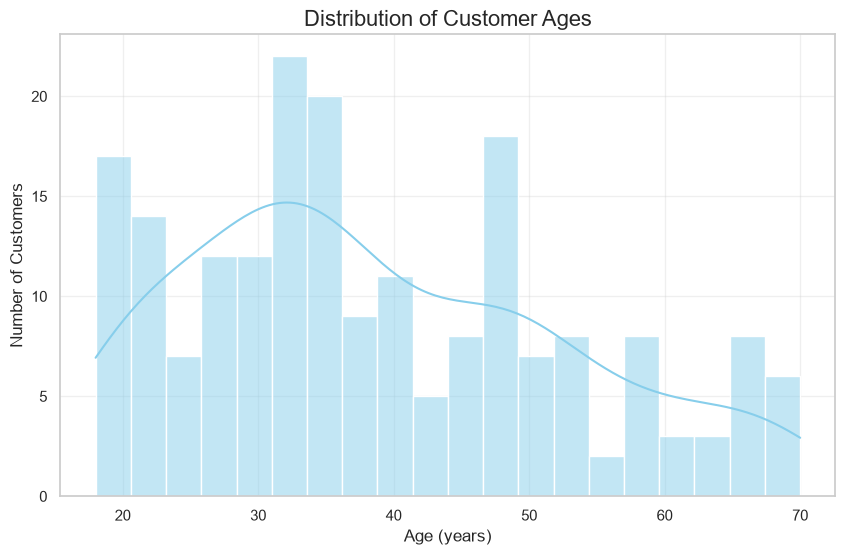

In [23]:
# Create histogram for Age
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Customer Ages', fontsize=16)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('../images/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

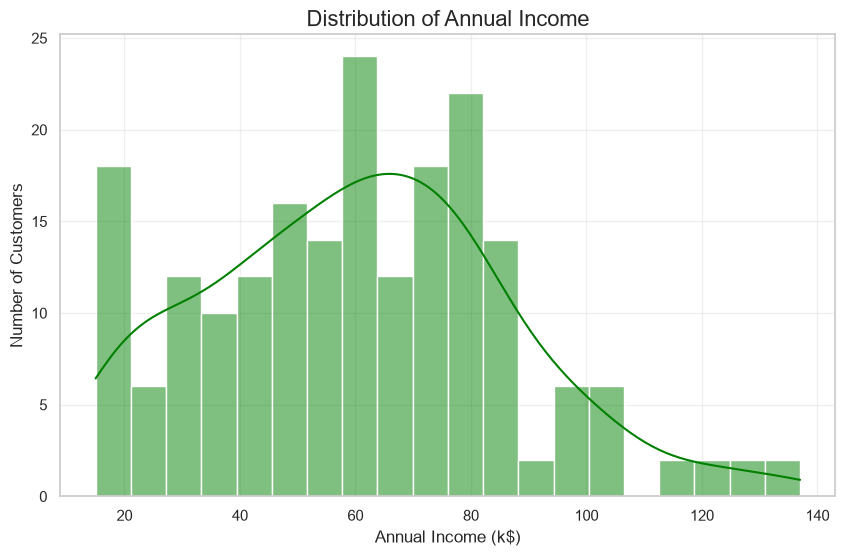

In [22]:
# Create histogram for Annual Income

plt.figure(figsize=(10,6))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='green')
plt.title('Distribution of Annual Income', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('../images/annual_income_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

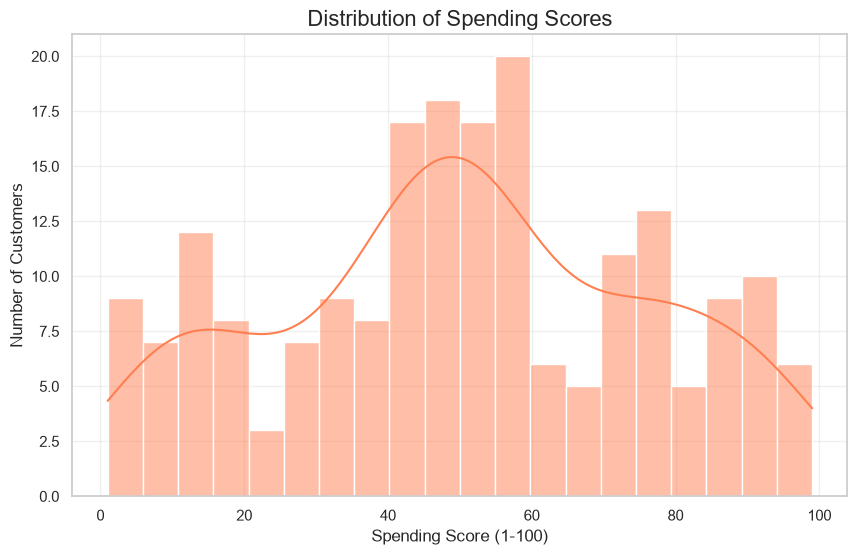

In [21]:
# Create histogram for Spending Score

plt.figure(figsize=(10,6))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, color='coral')
plt.title('Distribution of Spending Scores', fontsize=16)
plt.xlabel('Spending Score (1-100)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('../images/spending_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

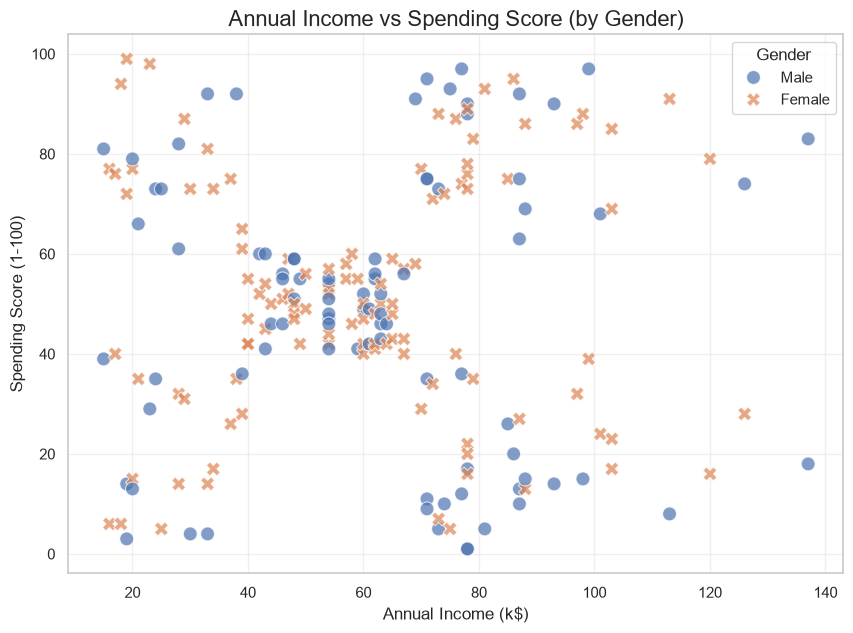

In [20]:
# Create scatter plot for Annual Income vs Spending Score

plt.figure(figsize=(10,7))
sns.scatterplot(data=df, 
                x='Annual Income (k$)', 
                y='Spending Score (1-100)',
                hue='Gender',
                style='Gender',
                s=100,
                alpha=0.7)
plt.title('Annual Income vs Spending Score (by Gender)', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Gender', loc='best')
plt.grid(alpha=0.3)
plt.savefig('../images/annual_income_vs_spending.png', dpi=300, bbox_inches='tight')
plt.show()

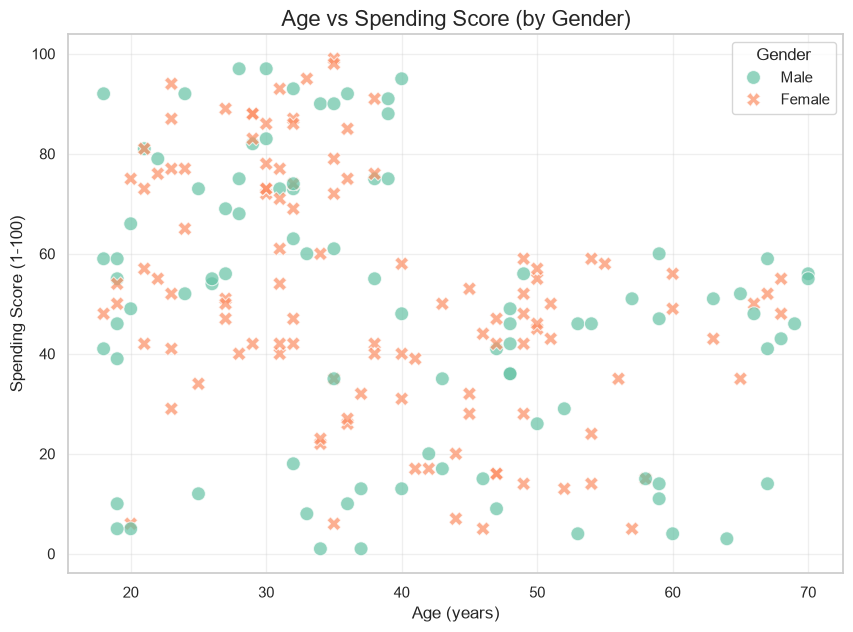

In [19]:
# Create scatter plot for Age vs Spending Score

plt.figure(figsize=(10,7))
sns.scatterplot(data=df, 
                x='Age', 
                y='Spending Score (1-100)',
                hue='Gender',
                style='Gender',
                s=100,
                alpha=0.7,
                palette='Set2')
plt.title('Age vs Spending Score (by Gender)', fontsize=16)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Gender', loc='best')
plt.grid(alpha=0.3)
plt.savefig('../images/age_vs_spending.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Drop CustomerID as it's not a real feature, just an identifier and will affect clustering if included.

df_model = df.drop('CustomerID', axis=1)

# Verify CustomerID is removed
df_model.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


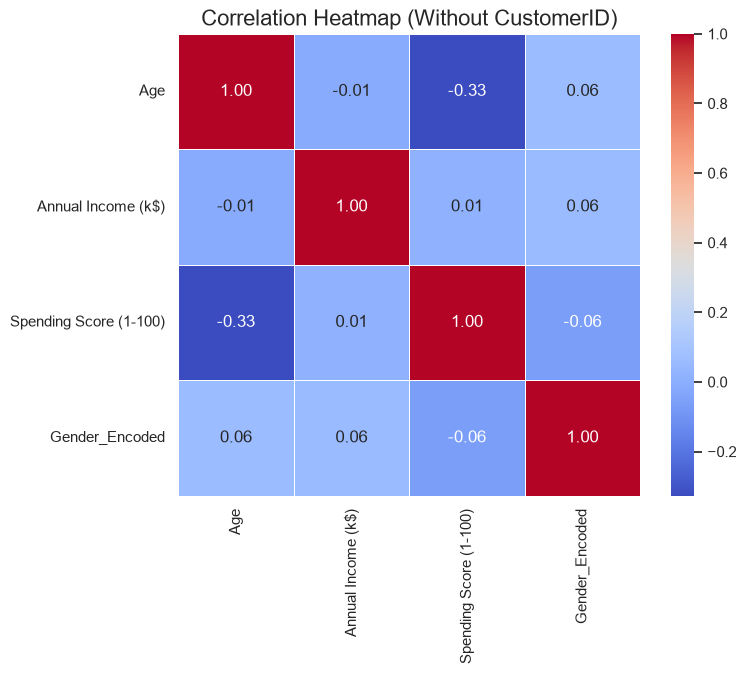

In [18]:
# Create a clean copy of the heatmap without CustomerID
df_model = df.drop('CustomerID', axis=1)

# Encode Gender
df_model['Gender_Encoded'] = df_model['Gender'].map({'Female': 0, 'Male': 1})
df_model = df_model.drop('Gender', axis=1)

# Calculate correlation
correlation_matrix = df_model.corr()

# Create heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap (Without CustomerID)', fontsize=16)
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

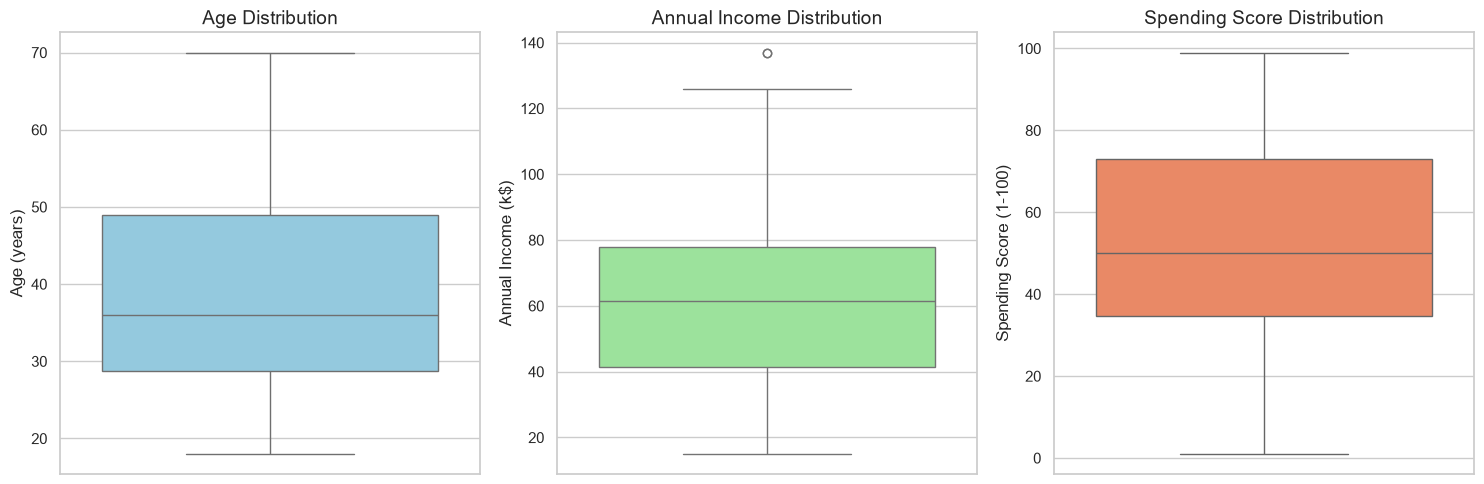

In [17]:
# Create boxplots for all numeric features
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Boxplot for Age
sns.boxplot(data=df, y='Age', ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_ylabel('Age (years)')

# Boxplot for Annual Income
sns.boxplot(data=df, y='Annual Income (k$)', ax=axes[1], color='lightgreen')
axes[1].set_title('Annual Income Distribution', fontsize=14)
axes[1].set_ylabel('Annual Income (k$)')

# Boxplot for Spending Score
sns.boxplot(data=df, y='Spending Score (1-100)', ax=axes[2], color='coral')
axes[2].set_title('Spending Score Distribution', fontsize=14)
axes[2].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.savefig('../images/boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

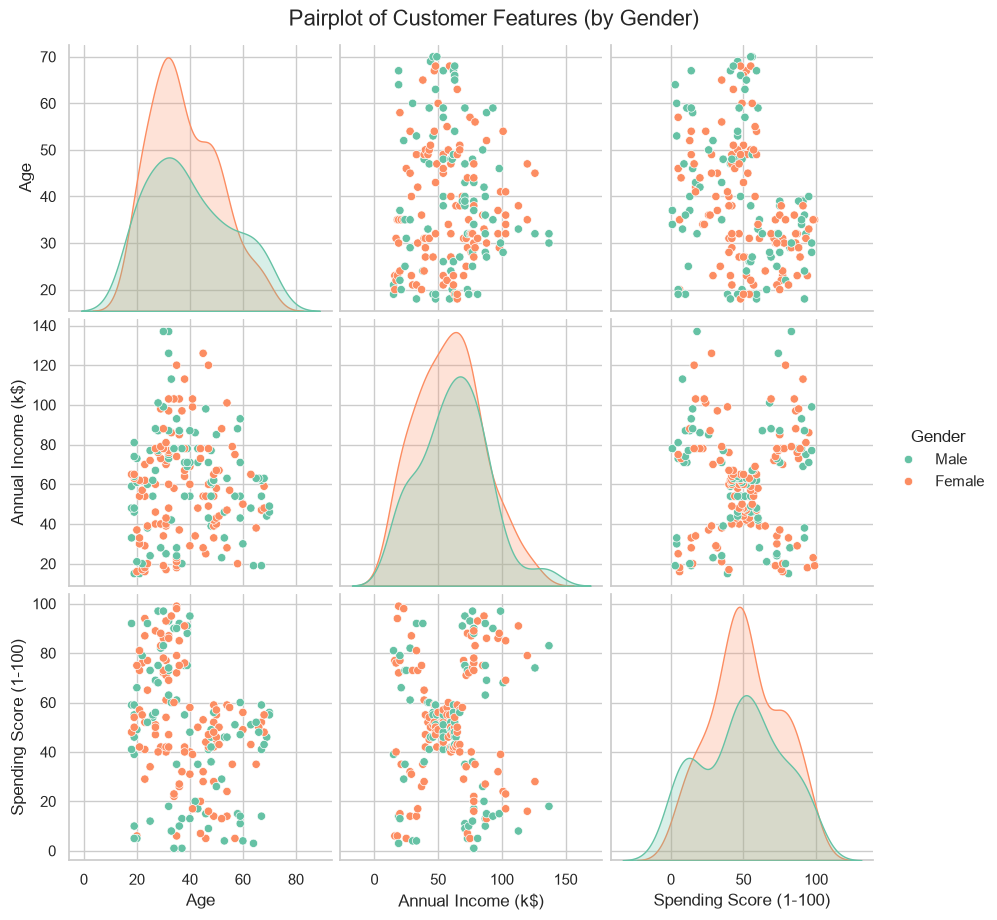

In [16]:
# Create pairplot (shows all relationships at once)


# First, encode Gender
df_plot = df.copy()
df_plot['Gender_Encoded'] = df_plot['Gender'].map({'Female': 0, 'Male': 1})

# Create pairplot
sns.pairplot(df_plot, 
             vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
             hue='Gender',
             diag_kind='kde',
             palette='Set2',
             height=3)
plt.suptitle('Pairplot of Customer Features (by Gender)', y=1.02, fontsize=16)
plt.savefig('../images/pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

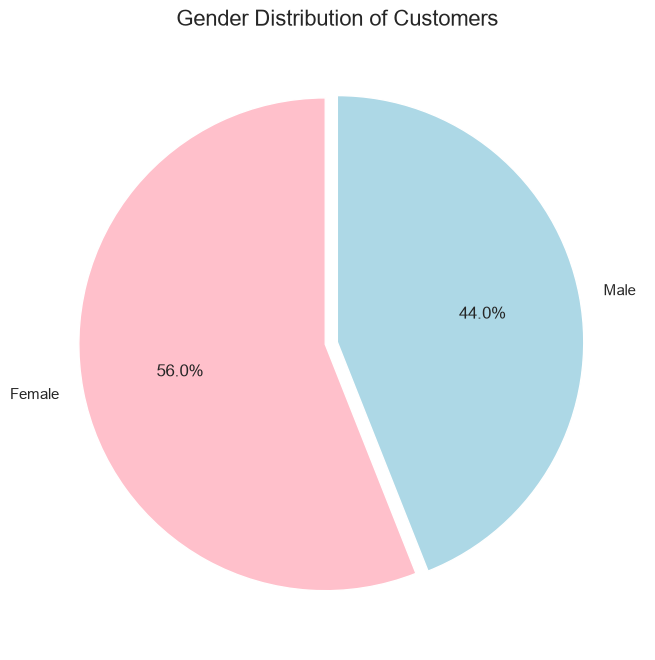

In [15]:
# Create pie chart for gender distribution
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(gender_counts.values, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', 
        colors=['pink', 'lightblue'],
        startangle=90,
        explode=(0.05, 0))
plt.title('Gender Distribution of Customers', fontsize=16)
plt.savefig('../images/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Create a folder for images if it doesn't exist
import os
if not os.path.exists('../images'):
    os.makedirs('../images')
    print("Images folder created!")
else:
    print("Images folder already exists.")
    

Images folder created!


In [24]:
# Create a summary statistics table
summary_stats = df.describe()
summary_stats

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000
